# <b><font color='coral'>Анализ данных по округам Непала</font></b>
Датасет - nepal - содержит геометрию округов и базовые социально-экономические показатели

In [10]:
# Загрузка необходимых библиотек (geopandas, geodatasets, модуль pyplot библиотеки matplotlib, seaborn)
from shapely.geometry import Point
import geopandas as gpd
import geodatasets as gds
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# Просмотр информации о датасете 
gds.data.query_name("geoda.nepal")


{'url': 'https://geodacenter.github.io/data-and-lab//data/nepal.zip',
 'license': 'NA',
 'attribution': 'Center for Spatial Data Science, University of Chicago',
 'name': 'geoda.nepal',
 'description': 'Health, poverty and education indicators for Nepal districts',
 'geometry_type': 'Polygon',
 'nrows': 75,
 'ncols': 62,
 'details': 'https://geodacenter.github.io/data-and-lab//nepal/',
 'hash': 'd7916568fe49ff258d0f03ac115e68f64cdac572a9fd2b29de2d70554ac2b20d',
 'filename': 'nepal.zip'}

### <font color='coral'>1. Загрузка данных</font>

In [17]:
# В переменную path сохраните путь к датасету
nepal_path = gds.get_path("geoda.nepal")

In [18]:
# Создаем GeoDataFrame - gdf_nepal с помощью функции read_file
gdf_nepal = gpd.read_file(nepal_path)
gdf_nepal


,id,name_1,name_2,district,depecprov,povindex,pcinc,pcincppp,pcincmp,malkids,...,HEALTDAMT,HUMDAMT,INDDAMT,MULTDAMT,SOCDAMT,TOURDAMT,TRANDAMT,WATDAMT,TOTDAMT,geometry
0,1,None,Dhaualagiri,Baglung,27.01,27.33,354,573,25613,42.9,...,3584409,172736,369324,8050858,1308661,0,15421,1996315,32542286,"POLYGON ((83.10834 28.6202, 83.1056 28.60976, ..."
1,2,None,Dhaualagiri,Mustang,31.51,31.16,1189,1922,85957,54.7,...,2253911,172736,0,3712798,633763,0,15421,0,14427364,"POLYGON ((83.99726 29.31675, 84 29.31576, 84 2..."
2,3,None,Dhaualagiri,Myagdi,30.03,28.54,636,1028,45986,47.5,...,2279653,172736,369324,11784759,964089,0,2688597,854545,31437665,"POLYGON ((83.50688 28.79306, 83.51024 28.78809..."
3,4,None,Dhaualagiri,Parbat,21.84,24.62,627,1013,45289,26.2,...,26574,0,369324,4741985,0,0,0,667767,10439874,"POLYGON ((83.70261 28.39837, 83.70435 28.39452..."
4,5,Central,Bagmati,Bhaktapur,22.58,19.43,854,1379,61686,26.9,...,1338957,172736,0,2421424,1652237,0,16431544,23818495,49073311,"POLYGON ((85.52173 27.71822, 85.52359 27.71375..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,71,West,Lumbini,Arghakhanchi,27.24,27.37,562,909,40635,31.0,...,556312,271481,0,6301876,666437,0,7429680,1996315,19143401,"POLYGON ((83.02333 28.10508, 83.02967 28.09924..."
71,72,West,Lumbini,Gulmi,27.36,27.42,465,752,33625,43.3,...,709990,172736,0,3712798,338080,0,0,2039001,12656803,"POLYGON ((83.19185 28.26453, 83.20638 28.25558..."
72,73,West,Lumbini,Nawalparasi,26.01,27.99,716,1157,51742,38.9,...,5853726,5593147,369324,6159076,903544,0,0,2069180,38866625,"POLYGON ((84.10302 27.86387, 84.09755 27.85927..."
73,74,West,Lumbini,Palpa,28.42,25.23,609,985,44031,35.9,...,673795,172736,0,5842196,1046358,0,0,854545,15516344,"POLYGON ((83.37988 27.95869, 83.37875 27.95583..."


In [ ]:
# С помощью метода crs объекта GeoDataFrame определим тип CRS 
gdf_nepal.crs



<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

### <font color='coral'>2. Построение карты округов</font>

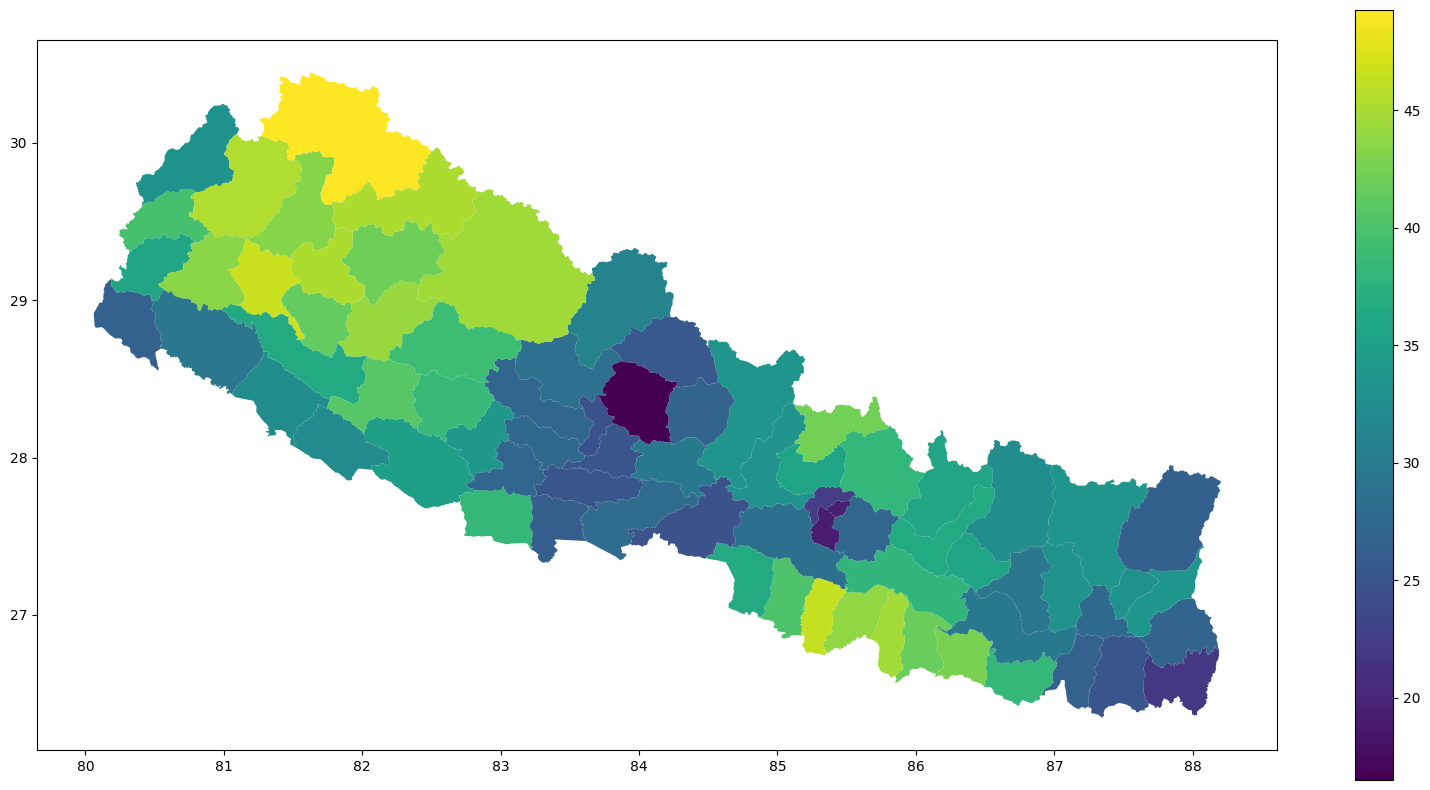

In [26]:
# Для gdf_nepal постройте карту с помощью функции plot
# В качестве раскраски выберите индекс бедности населения povindex
# Для параметра legend укажите значение True
fig, ax = plt.subplots(figsize=(20, 10))
gdf_nepal.plot(column='povindex', legend=True, ax=ax)
plt.show()


In [24]:
# То же самое сделайте в интерактивном варианте
gdf_nepal.explore('povindex', legend = False)

### <font color='coral'>3. Измерение расстояний до Катманду</font>

In [27]:
# Для того, чтобы измерить расстояние, необходимо перевести геодатафрейм к CRS Web Mercator (EPSG:3857)
# В переменную gdf_nepal_m сохраните геодатафрейм с CRS Web Mercator
gdf_nepal_m = gdf_nepal.to_crs(epsg=3857)
gdf_nepal_m

,id,name_1,name_2,district,depecprov,povindex,pcinc,pcincppp,pcincmp,malkids,...,HEALTDAMT,HUMDAMT,INDDAMT,MULTDAMT,SOCDAMT,TOURDAMT,TRANDAMT,WATDAMT,TOTDAMT,geometry
0,1,None,Dhaualagiri,Baglung,27.01,27.33,354,573,25613,42.9,...,3584409,172736,369324,8050858,1308661,0,15421,1996315,32542286,"POLYGON ((9251577.8 3327393.903, 9251272.901 3..."
1,2,None,Dhaualagiri,Mustang,31.51,31.16,1189,1922,85957,54.7,...,2253911,172736,0,3712798,633763,0,15421,0,14427364,"POLYGON ((9350532.328 3416023.505, 9350837.227..."
2,3,None,Dhaualagiri,Myagdi,30.03,28.54,636,1028,45986,47.5,...,2279653,172736,369324,11784759,964089,0,2688597,854545,31437665,"POLYGON ((9295943.55 3349333.764, 9296317.242 ..."
3,4,None,Dhaualagiri,Parbat,21.84,24.62,627,1013,45289,26.2,...,26574,0,369324,4741985,0,0,0,667767,10439874,"POLYGON ((9317732.35 3299292.46, 9317925.99 32..."
4,5,Central,Bagmati,Bhaktapur,22.58,19.43,854,1379,61686,26.9,...,1338957,172736,0,2421424,1652237,0,16431544,23818495,49073311,"POLYGON ((9520235.27 3213493.974, 9520442.499 ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,71,West,Lumbini,Arghakhanchi,27.24,27.37,562,909,40635,31.0,...,556312,271481,0,6301876,666437,0,7429680,1996315,19143401,"POLYGON ((9242114.896 3262228.882, 9242820.665..."
71,72,West,Lumbini,Gulmi,27.36,27.42,465,752,33625,43.3,...,709990,172736,0,3712798,338080,0,0,2039001,12656803,"POLYGON ((9260874.242 3282365.634, 9262492.159..."
72,73,West,Lumbini,Nawalparasi,26.01,27.99,716,1157,51742,38.9,...,5853726,5593147,369324,6159076,903544,0,0,2069180,38866625,"POLYGON ((9362305.329 3231821.565, 9361696.38 ..."
73,74,West,Lumbini,Palpa,28.42,25.23,609,985,44031,35.9,...,673795,172736,0,5842196,1046358,0,0,854545,15516344,"POLYGON ((9281805.248 3243766.382, 9281680.401..."


In [30]:
# Также для вычисления расстояния нам необходимо вычислить центроиды для каждого округа
# В gdf_nepal_m создайте столбец centroid и запишите в него результат работы функции centroid
gdf_nepal_m['centroid'] = gdf_nepal_m.geometry.centroid

In [31]:
# Создайте геодатафрейм katmandu_point с координатами Катманду с CRS Web Mercator (EPSG:3857)
# Координаты Катманду: 85.3240, 27.7172
katmandu_point = gpd.GeoDataFrame(geometry=[Point(85.3240, 27.7172)], crs='EPSG:4326').to_crs(epsg=3857)
katmandu_point

,geometry
0,POINT (9498224.232 3213365.74)


In [32]:
# В gdf_nepal_m добавьте столбец distance_to_Katmandu_km
# Заполните этот столбец результатом работы функции distance (вычисленный в км)
gdf_nepal_m['distance_to_Katmandu_km'] = gdf_nepal_m['centroid'].distance(katmandu_point.geometry.iloc[0]) / 1000
gdf_nepal_m

,id,name_1,name_2,district,depecprov,povindex,pcinc,pcincppp,pcincmp,malkids,...,INDDAMT,MULTDAMT,SOCDAMT,TOURDAMT,TRANDAMT,WATDAMT,TOTDAMT,geometry,centroid,distance_to_Katmandu_km
0,1,None,Dhaualagiri,Baglung,27.01,27.33,354,573,25613,42.9,...,369324,8050858,1308661,0,15421,1996315,32542286,"POLYGON ((9251577.8 3327393.903, 9251272.901 3...",POINT (9267597.64 3292861.432),243.943006
1,2,None,Dhaualagiri,Mustang,31.51,31.16,1189,1922,85957,54.7,...,0,3712798,633763,0,15421,0,14427364,"POLYGON ((9350532.328 3416023.505, 9350837.227...",POINT (9335257.18 3373304.318),228.338803
2,3,None,Dhaualagiri,Myagdi,30.03,28.54,636,1028,45986,47.5,...,369324,11784759,964089,0,2688597,854545,31437665,"POLYGON ((9295943.55 3349333.764, 9296317.242 ...",POINT (9290938.044 3318891.368),232.600993
3,4,None,Dhaualagiri,Parbat,21.84,24.62,627,1013,45289,26.2,...,369324,4741985,0,0,0,667767,10439874,"POLYGON ((9317732.35 3299292.46, 9317925.99 32...",POINT (9315315.311 3275624.377),193.214419
4,5,Central,Bagmati,Bhaktapur,22.58,19.43,854,1379,61686,26.9,...,0,2421424,1652237,0,16431544,23818495,49073311,"POLYGON ((9520235.27 3213493.974, 9520442.499 ...",POINT (9511461.082 3208357.072),14.152771
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,71,West,Lumbini,Arghakhanchi,27.24,27.37,562,909,40635,31.0,...,0,6301876,666437,0,7429680,1996315,19143401,"POLYGON ((9242114.896 3262228.882, 9242820.665...",POINT (9248572.601 3237437.063),250.809421
71,72,West,Lumbini,Gulmi,27.36,27.42,465,752,33625,43.3,...,0,3712798,338080,0,0,2039001,12656803,"POLYGON ((9260874.242 3282365.634, 9262492.159...",POINT (9273910.941 3260804.504),229.274702
72,73,West,Lumbini,Nawalparasi,26.01,27.99,716,1157,51742,38.9,...,369324,6159076,903544,0,0,2069180,38866625,"POLYGON ((9362305.329 3231821.565, 9361696.38 ...",POINT (9345877.42 3202875.749),152.707534
73,74,West,Lumbini,Palpa,28.42,25.23,609,985,44031,35.9,...,0,5842196,1046358,0,0,854545,15516344,"POLYGON ((9281805.248 3243766.382, 9281680.401...",POINT (9309166.162 3225942.453),189.475929


### <font color='coral'>4. Дополнительное задание (опционально)</font>

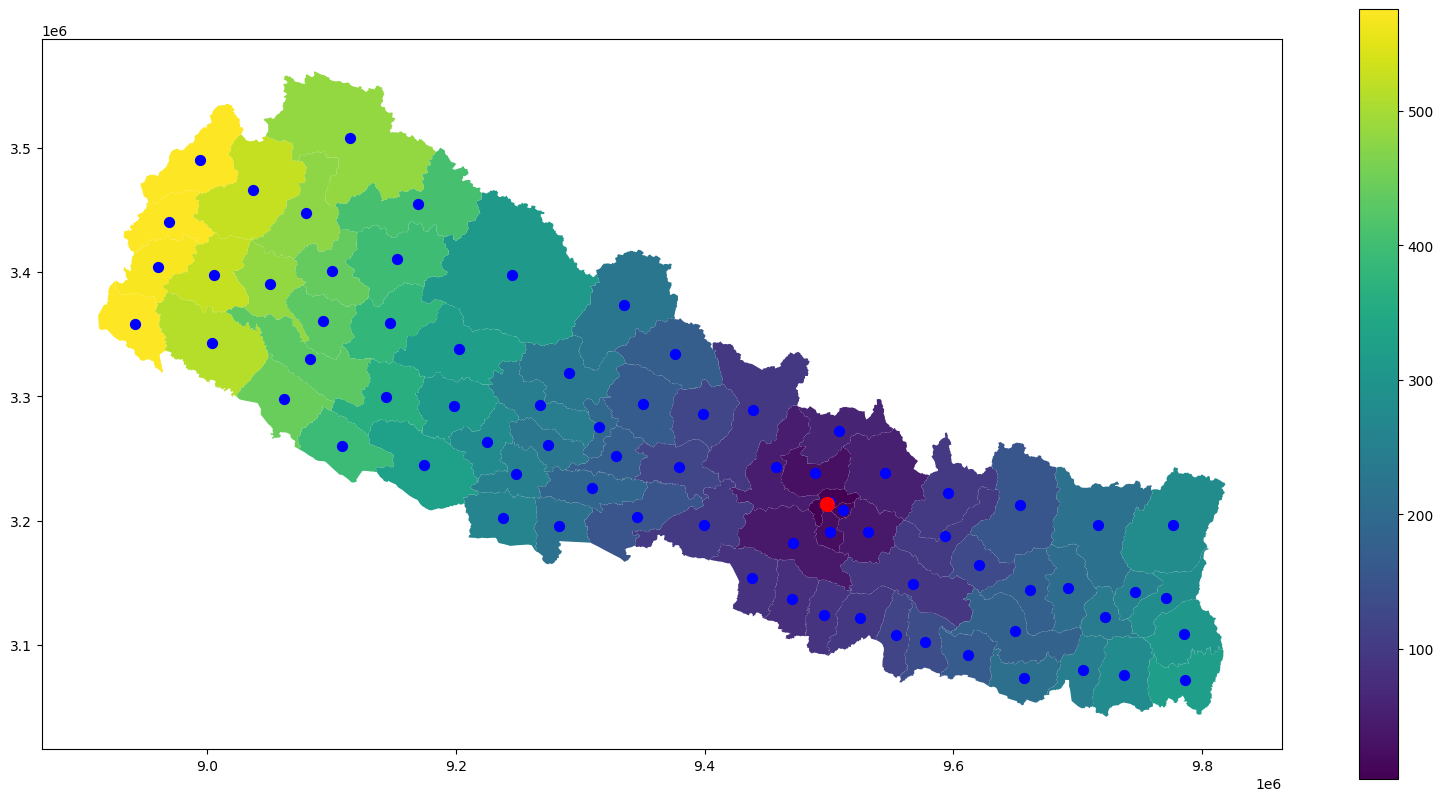

In [34]:
# Постройте карту Непала со следующими требованиями:
# 1. Цвет обозначает расстояние до Катманду
# 2. На каждом округе обозначена точка - центроид округа
# 3. Отдельно отмечена столица - Катманду
# Создадим объект Фигура - он понадобится для регулировки осей ax
gdf_nepal_m.plot(column='distance_to_Katmandu_km', legend=True, figsize=(20, 10))
gdf_nepal_m['centroid'].plot(ax=plt.gca(), color='blue', markersize=50)
katmandu_point.plot(ax=plt.gca(), color='red', markersize=100)
plt.show()

In [39]:
gdf_nepal_m['00'] = gdf_nepal_m['population']/1000
gdf_nepal_m[['district', '00', 'geometry']].explore('00')

### <font color='coral'>5. Столбчатая диаграмма</font>

,district,population
6,Kathmandu,1688131
25,Morang,958579
74,Rupandehi,873314
30,Jhapa,807308
16,Sarlahi,765959
47,Kailali,765487
12,Dhanusa,752253
27,Sunsari,750319
21,Rautahat,680659
18,Bara,680094


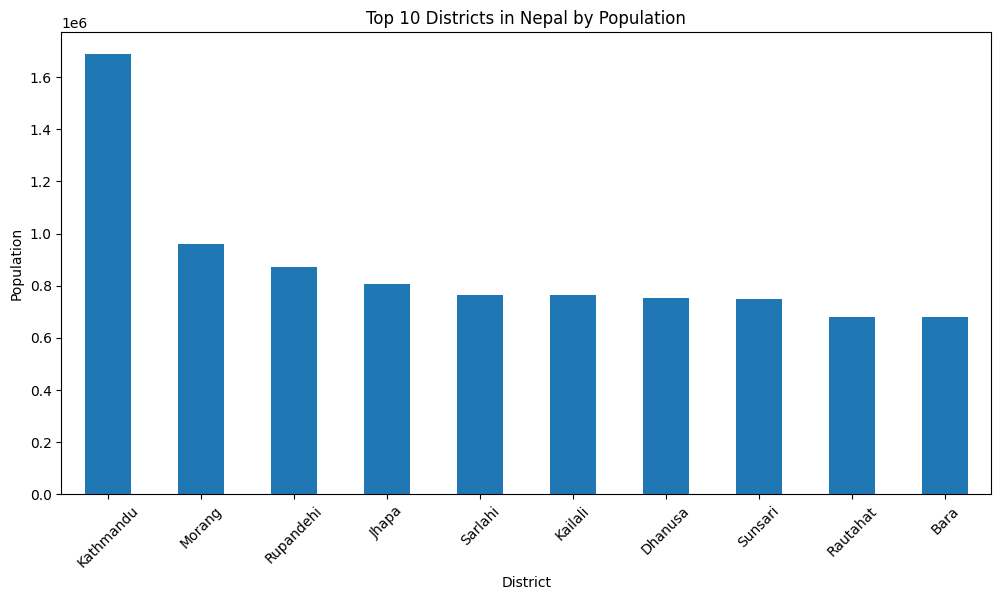

In [37]:
# Постройте столбчатую диаграмму, показывающую топ-10 округов Непала по количеству населения (population)
# 1. Создайте датафрейм df_nepal_top10, в который отфильтруйте из исходного gdf_nepal 10 округов с наибольшим населением
# Возьмите только 2 столбца: district и population
df_nepal_top10 = gdf_nepal[['district', 'population']].nlargest(10, 'population')
display(df_nepal_top10)
df_nepal_top10.plot(kind='bar', x='district', y='population', legend=False, figsize=(12, 6))
plt.xlabel('District')
plt.ylabel('Population')
plt.title('Top 10 Districts in Nepal by Population')
plt.xticks(rotation=45)
plt.show()

C:\Users\Vitaliy\AppData\Local\Temp\ipykernel_2844\1364489571.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='district', y='population', data=df_nepal_top10, palette='viridis')


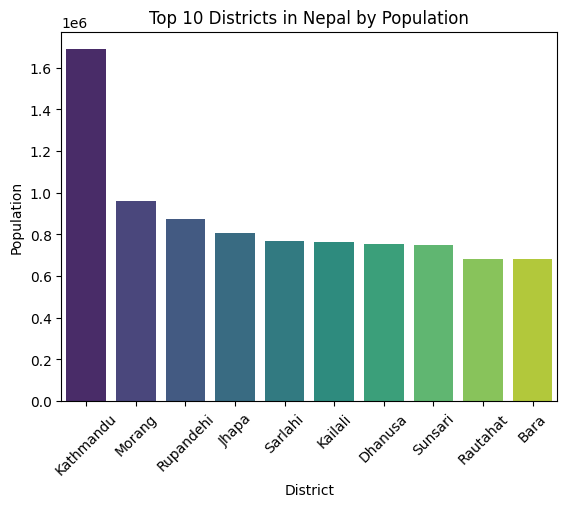

In [38]:
# 2. С помощью библиотеки seaborn постройте столбчатую диаграмму (barplot) со следующими параметрами:
# по оси x - district
# по оси y - population
# data = df_nepal_top10
# цветовая палитра - viridis
# С помощью функции xticks и параметра rotation из библиотеки matplotlib поверните названия округов на 45 градусов
sns.barplot(x='district', y='population', data=df_nepal_top10, palette='viridis')
plt.xlabel('District')
plt.ylabel('Population')
plt.title('Top 10 Districts in Nepal by Population')
plt.xticks(rotation=45)
plt.show()